# Simulating a Quantum Field Theory on a Gate-Based Quantum Computer

## Reproducing Section IV.1 of *Simulating Quantum Field Theories on Gate-Based Quantum Computers* (arXiv:2401.04496) with Classiq

**Reference paper:** Gayathree M. Vinod and Anil Shaji, *Simulating quantum field theories on gate-based quantum computers*, [arXiv:2401.04496](https://arxiv.org/abs/2401.04496).

### The model, and why it is worth simulating

Quantum field theory is the language of relativistic particle physics: it describes how quanta are created, annihilated and scattered, and it underlies the Standard Model. What makes a field theory hard to simulate is exactly what makes it physical — **particle number is not conserved**. A fermion can emit a boson and become a two-particle state, that boson can split again, and the state space is therefore a Fock space spanned by every allowed particle content. Representing such a state classically costs memory that grows exponentially with the number of modes, which is one of the oldest arguments for building quantum computers in the first place.

The theory studied here is the **Yukawa model in $1+1$ dimensions**: a Dirac fermion field $\Psi$, whose quanta we call "protons" (mass $m_F$), coupled to a real scalar field $\phi$, the "pions" (mass $m_\pi$), through the interaction $-\lambda\,\phi\,\bar\Psi\Psi$. It is the low-dimensional caricature of the theory Hideki Yukawa proposed in 1935 to explain the nuclear force as meson exchange between nucleons, and it has become a standard testbed for field-theory simulation algorithms: it contains the essential difficulty of an interacting, particle-number-violating Fock space, while remaining small enough that an exact classical answer is available to check against. To make the Hilbert space finite, the paper works in the **light-front** formulation with discretized momenta (Section 1); the result is a Hamiltonian acting on twelve qubits.

### The physical process being tracked

The experiment of Section IV.1 is a single emission event. We prepare one fermion carrying two units of longitudinal momentum, written $|f\rangle_2$, and let it evolve. Conservation of momentum and of fermion number leaves exactly one other state accessible: a fermion carrying one unit of momentum accompanied by an emitted boson carrying the other unit, $|f\rangle_1 \otimes |\phi\rangle_1$. The fermion therefore does not decay irreversibly — it emits and reabsorbs the boson coherently, so the system performs a **Rabi-like oscillation** between the one-particle and the two-particle configuration. The observable plotted throughout is the probability of finding the system in the emitted state,

$$
P(t) \;=\; \Big|\big\langle\, f_1\,\phi_1 \,\big|\, \psi(t)\,\big\rangle\Big|^2 ,
\qquad
|\psi(0)\rangle \;=\; |f\rangle_2 ,
$$

as a function of light-front time $t$, measured in units of $m_\pi^{-1}$ — the inverse pion mass, which is the natural clock of the model because $m_\pi$ is the mass scale we set to one. (Once the register layout of Section 4 is fixed these two states become particular computational basis kets, but the binary strings are bookkeeping; the physics is simply "one fermion" versus "fermion plus pion".) Reproducing this curve over $t \in [0, 1]$ is **Fig. 2** of the paper.

### What this notebook computes

We build the light-front Hamiltonian once and then evolve it in two independent ways, so that each serves as a check on the other:

1. **Exact evolution** — sparse matrix exponentiation, $|\psi(t)\rangle = e^{-iHt}|\psi(0)\rangle$, with SciPy's `expm_multiply`. This is the classical reference and reproduces the paper's Fig. 2.
2. **Gate-based Hamiltonian simulation** — a parametrized first-order Suzuki–Trotter circuit built and synthesized with the **Classiq SDK**, sampled on a statevector simulator and exported as `qft_simulation.qmod`.

**GitHub issue [#580](https://github.com/Classiq/classiq-library/issues/580) mapping.**
The issue names the tracked state as $|f_1\rangle = |100\text{-}000\text{-}01\text{-}00\text{-}00\rangle$;
following Section IV.1 and Fig. 2 of the paper, this is shorthand for the **full target ket**
$|f\rangle_1 \otimes |\phi\rangle_1$, evolved from the **initial state** $|f\rangle_2 = |010\ 000\ 00\ 00\ 00\rangle$.
The issue deliverable is a **comparison plot** (exact vs. Classiq Trotter) of that population — distinct from paper Fig. 2, which shows exact evolution only.

Comparing them answers the practical question the paper poses: for an interacting field theory of this size, how many Trotter steps does a digital quantum simulation need before its output becomes indistinguishable from the true dynamics, and what circuit resources does that cost?

### Contents

1. [The physical model: light-front Yukawa theory](#model)
2. [Fock space, conserved charges, and the two-level structure](#fock)
3. [The light-front Hamiltonian](#hamiltonian)
4. [Encoding the field theory into qubits](#encoding)
5. [Building the Hamiltonian as a Pauli-string operator](#pauli)
6. [Exact reference evolution](#exact)
7. [Analytic cross-check: the two-level (Rabi) reduction](#rabi)
8. [Reproducing the paper's Fig. 2](#fig2)
9. [Trotterization: theory and classical error analysis](#trotter)
10. [The Classiq model](#classiq)
11. [Synthesis and execution](#execution)
12. [Validation report](#validation)
13. [Results: exact vs. gate-based simulation](#results)
14. [Resource summary and conclusions](#summary)

### Environment

This notebook was developed and tested with **`classiq` 1.19.1** (earlier releases such as 0.104.x use deprecated execution APIs — in particular `batch_sample`, which is replaced here by `ExecutionSession.sample`). The first cell installs dependencies and, on a fresh machine, performs the one-time Classiq authentication.

> **Run order.** Use **Restart kernel → Run All** before reviewing plots or opening a PR.
> Section 13 depends on the Classiq time sweep (cell defining `populations_trotter`) finishing
> before the comparison and deviation plots — out-of-order execution causes
> `NameError: populations_trotter is not defined`. The sweep is 41 time points × 8192 shots
> inside one `ExecutionSession` (~10+ minutes on the cloud).

In [1]:
# %pip install -U "classiq==1.19.1" numpy scipy matplotlib
# import classiq
# classiq.authenticate()  # one-time browser login on a new machine

In [2]:
import itertools
import math
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import expm_multiply

import classiq
from classiq import (
    CReal,
    IndexedPauli,
    Output,
    Pauli,
    QArray,
    QBit,
    SparsePauliOp,
    SparsePauliTerm,
    X,
    allocate,
    calculate_state_vector,
    qfunc,
    show,
    suzuki_trotter,
    synthesize,
    write_qmod,
)

RNG_SEED = 1234
np.random.seed(RNG_SEED)

print(f"classiq     {classiq.__version__}")
print(f"numpy       {np.__version__}")
print(f"scipy       {__import__('scipy').__version__}")
print(f"matplotlib  {__import__('matplotlib').__version__}")

classiq     1.19.1
numpy       2.2.4
scipy       1.15.2
matplotlib  3.10.8


c:\Users\tchau\AppData\Local\Programs\Python\Python311\Lib\site-packages\classiq\__init__.py:108: UserWarning: 'nest_asyncio2' is not installed; falling back to the legacy 'nest_asyncio'. 'nest_asyncio2' ships with modern Jupyter (ipykernel >= 7.3); consider upgrading your Jupyter installation, for example: pip install --upgrade jupyter ipykernel
  enable_jupyter_notebook()


<a id="model"></a>
## 1. The physical model: light-front Yukawa theory in $1+1$ dimensions

The theory simulated in Section IV.1 of the paper is a $(1+1)$-dimensional model of a Dirac fermion field $\Psi$ (mass $m_F$, the "proton") Yukawa-coupled to a real scalar field $\phi$ (mass $m_B$, the "pion"):

$$
\mathcal{L} \;=\; \tfrac{1}{2}\,\partial_\mu\phi\,\partial^\mu\phi \;-\; \tfrac{1}{2} m_B^2 \phi^2
\;+\; \bar\Psi\big(i\gamma^\mu \partial_\mu - m_F\big)\Psi \;-\; \lambda\, \phi\, \bar\Psi \Psi .
$$

The boson of this model plays the role of the pion, so we write its mass as $m_\pi$ and use it as the unit for everything else: setting $m_B \equiv m_\pi = 1$ means every energy in this notebook is measured in units of $m_\pi$ and every time in units of $m_\pi^{-1}$. The Section IV.1 parameters are then a fermion mass $m_F = 6.7$ (a proton-to-pion mass ratio) and a bare coupling $\lambda = 4.0$, with the rescaled coupling that actually appears in the Hamiltonian given by

$$
g \;=\; \frac{\lambda}{\sqrt{4\pi}} \;\approx\; 1.1284 .
$$

### 1.1 Why the light front?

Instead of quantizing on surfaces of constant ordinary time $x^0$, **light-front quantization** uses the coordinates

$$
x^\pm \;=\; x^0 \pm x^1 ,
$$

and takes $x^+$ as the evolution parameter ("light-front time"). The momentum components conjugate to these coordinates are

$$
p^\pm \;=\; p^0 \pm p^1 ,
$$

and although they look symmetric they play completely different physical roles:

* **$p^+$ is the longitudinal (light-front) momentum.** It is the *kinematical* variable: fixed at the moment a quantum is created, strictly positive for every physical quantum, additive over particles, and independent of the interactions. It is the light-front analogue of ordinary momentum, and it is the quantity that gets discretized into integer mode numbers below. Summing it over all quanta gives the conserved total-momentum operator
  $$P^+ \;=\; \sum_i p^+_i ,$$
  which commutes with the Hamiltonian and therefore labels states once and for all.
* **$p^-$ is the light-front energy.** It is the *dynamical* variable, the generator of translations in light-front time $x^+$. Its total $P^-$ is the Hamiltonian of the theory: it carries all the interactions and it is the operator we exponentiate in order to evolve the state.

The free-particle mass-shell condition $p_\mu p^\mu = m^2$ ties the two together,

$$
p^+ p^- = m^2
\quad\Longrightarrow\quad
p^- = \frac{m^2}{p^+} ,
$$

which is the light-front counterpart of $E = p^2/2m$: a quantum that carries only a small share of the longitudinal momentum is expensive in light-front energy.

Two structural consequences make this frame ideal for Hamiltonian simulation:

* **Positivity of $p^+$.** Every physical quantum carries $p^+ > 0$. Since total $P^+$ is conserved and all contributions are positive, a state of fixed total $P^+$ can contain only a *finite* number of quanta — the Fock space truncates itself.
* **A simple vacuum.** Because no combination of $p^+>0$ quanta can carry total $P^+ = 0$, the free vacuum is an eigenstate of the full interacting theory. There is no vacuum-structure problem to solve before doing dynamics.

Dynamics is generated by the light-front Hamiltonian $P^-$ through the light-front Schrödinger equation

$$
i\,\frac{\partial}{\partial x^+}\,|\psi(x^+)\rangle \;=\; \frac{1}{2}\,P^-\,|\psi(x^+)\rangle ,
$$

and the invariant mass of a state follows from $M^2 = P^+ P^-$ (there are no transverse directions in $1+1$D).

### 1.2 Discretized Light-Cone Quantization (DLCQ)

To obtain a finite-dimensional problem, the longitudinal direction $x^-$ is compactified on an interval of length $2L$. Momenta then come in integer multiples of a fundamental unit,

$$
k^+_n = \frac{2\pi n}{L}\,\cdot\tfrac{1}{2}\; \propto\; n , \qquad n = 1, 2, 3, \dots ,
$$

and every particle in the theory is labelled by its positive integer mode number $n$. The **harmonic resolution**

$$
K \;=\; \frac{L}{2\pi}\,P^+
$$

counts the total number of momentum units in a state and is an exact constant of motion. Following the paper, we choose $L = 2\pi\, m_\pi^{-1}$, which makes $P^-$ numerically identical to the Hamiltonian $H$ we exponentiate below, with time measured in units of $m_\pi^{-1}$. This is the clock used on the horizontal axes of all figures in this notebook.

The field operators are expanded in these discrete modes with three families of ladder operators, all obeying the usual algebra:

$$
\{ b_n, b_{n'}^\dagger \} = \delta_{nn'} \;\; \text{(fermions)}, \qquad
\{ d_n, d_{n'}^\dagger \} = \delta_{nn'} \;\; \text{(antifermions)}, \qquad
[\, a_n, a_{n'}^\dagger \,] = \delta_{nn'} \;\; \text{(bosons)} .
$$

For the bosons it is convenient to also define the **rescaled operators** used throughout the paper's appendix,

$$
c_n \;=\; \frac{a_n}{\sqrt{n}}, \qquad c_n^\dagger \;=\; \frac{a_n^\dagger}{\sqrt{n}} ,
$$

which absorb the $1/\sqrt{k^+}$ normalization of the scalar mode functions.

### 1.3 The truncations

Two cutoffs make the Hilbert space finite:

* **Mode cutoff $N_\text{max}$:** only modes $n = 1, \dots, N_\text{max}$ are kept for each species. Section IV.1 uses $N_\text{max} = 3$.
* **Bosonic modal cutoff:** each bosonic mode can hold at most $3$ quanta (occupancies $0..3$, i.e. $4$ levels $\Rightarrow$ $2$ qubits per mode).

A third, purely numerical cutoff $\Lambda = 2048$ regulates the mode sums inside the *self-induced inertias* (Section 3).

In [3]:
# --- Section IV.1 parameters (arXiv:2401.04496) ------------------------------
N_MAX = 3  # number of momentum modes per particle species (N_F = N_A = N_B)
N_MODALS = 3  # bosonic modal cutoff m (occupancies 0..3)
LAMBDA_COUPLING = 4.0  # bare Yukawa coupling lambda
M_F = 6.7  # fermion (proton) mass, in pion-mass units
M_B = 1.0  # boson (pion) mass, in pion-mass units
LAMBDA_CUTOFF = 2048  # harmonic-resolution cutoff in the inertia sums

G = LAMBDA_COUPLING / math.sqrt(4 * math.pi)  # g = lambda / sqrt(4 pi)

# --- Qubit register layout ----------------------------------------------------
# Fermions and antifermions are two distinct species. Each has N_MAX momentum
# modes, and each mode holds 0 or 1 quanta (Pauli exclusion), so one qubit per
# mode suffices -> the factor 2 below counts the two species, not two qubits
# per mode. Each bosonic mode instead holds 0..N_MODALS quanta and needs
# ceil(log2(N_MODALS + 1)) qubits to store that occupancy in binary.
QUBITS_PER_BOSON = math.ceil(math.log2(N_MODALS + 1))  # = 2
N_FERMIONIC_QUBITS = 2 * N_MAX  # 3 fermion modes + 3 antifermion modes = 6
N_BOSONIC_QUBITS = QUBITS_PER_BOSON * N_MAX  # 2 qubits x 3 bosonic modes  = 6
N_QUBITS = N_FERMIONIC_QUBITS + N_BOSONIC_QUBITS  # 6 + 6 = 12
DIM = 2**N_QUBITS  # 4096

print(f"g = {G:.6f}")
print(f"fermionic qubits: {N_FERMIONIC_QUBITS}  (fermion modes + antifermion modes)")
print(f"bosonic qubits  : {N_BOSONIC_QUBITS}  ({QUBITS_PER_BOSON} per mode)")
print(f"qubits: {N_QUBITS}  (Hilbert-space dimension {DIM})")

g = 1.128379
qubits: 12  (Hilbert-space dimension 4096)


<a id="fock"></a>
## 2. Fock space, conserved charges, and the two-level structure

Having fixed the model, we now describe the space it lives in. This section sets up the Fock basis, identifies the two quantities that the interaction cannot change, and uses them to show that the particular experiment of Section IV.1 reduces to a problem with only two accessible states — which is why the paper\'s Fig. 2 is a clean oscillation and why we can check the whole simulation against a closed-form formula later on.

A basis state of the truncated theory is a Fock state

$$
|\, \underbrace{n^f_1 n^f_2 n^f_3}_{\text{fermions}}\ \underbrace{n^{\bar f}_1 n^{\bar f}_2 n^{\bar f}_3}_{\text{antifermions}}\ \underbrace{s_1}_{\text{boson }1}\ \underbrace{s_2}_{\text{boson }2}\ \underbrace{s_3}_{\text{boson }3} \,\rangle,
$$

where $n^f_k, n^{\bar f}_k \in \{0,1\}$ are fermionic occupations and $s_k \in \{0,1,2,3\}$ are bosonic occupancies written as two binary digits. This is exactly the paper's ket notation, e.g. the initial state $|f\rangle_2 = |010\ 000\ 00\ 00\ 00\rangle$ has a single fermion in momentum mode $2$.

### 2.1 Constants of motion

Two operators commute with the full Hamiltonian and are therefore **constants of motion** — conserved properties of the theory whose values are fixed for all time by the initial condition:

$$
K \;=\; \sum_{n=1}^{N_\text{max}} n \left( b_n^\dagger b_n + d_n^\dagger d_n + a_n^\dagger a_n \right)
\qquad \text{(harmonic resolution / total momentum)},
$$

$$
Q \;=\; \sum_{n=1}^{N_\text{max}} \left( b_n^\dagger b_n - d_n^\dagger d_n \right)
\qquad \text{(fermion number / charge)}.
$$

Both are diagonal in the Fock basis, and $[H, K] = [H, Q] = 0$ (verified numerically in Section 12). Physically, $K$ counts the total longitudinal momentum in units of the fundamental momentum quantum, and $Q$ is the net fermion number, so the two statements simply say that the interaction can redistribute momentum and charge among quanta but can neither create nor destroy them.

Because these quantities are conserved *and* diagonal in the Fock basis, every basis state carries a well-defined pair of **quantum numbers** $(K, Q)$, and the Hamiltonian is block diagonal with respect to them — it can never connect states with different $(K, Q)$. This is what simplifies the dynamical problem: instead of a single $4096$-dimensional evolution, the register decomposes into independent invariant subspaces, and a state prepared inside one of them is confined to that subspace forever. Solving the dynamics only ever requires understanding one block.

### 2.2 The $(K, Q) = (2, 1)$ sector has exactly two states

The initial state $|f\rangle_2$ carries $K = 2$ and $Q = 1$, so by the argument above the evolution is confined to that sector for all times, and we can enumerate the sector by hand. Note that "cost" here is bookkeeping in $K$ — momentum units, not energy and not qubits. Charge $Q = 1$ demands one more fermion than antifermion, and the cheapest way to supply it is a single fermion in mode $n = 1$, which already spends $K = 1$. The configurations with total $K = 2$ are then:

| state | content | $K$ bookkeeping |
|---|---|---|
| $\lvert f\rangle_2 = \lvert 010\ 000\ 00\ 00\ 00\rangle$ | one fermion in mode 2 | $2$ |
| $\lvert f\rangle_1 \otimes \lvert\phi\rangle_1 = \lvert 100\ 000\ 01\ 00\ 00\rangle$ | fermion in mode 1 + boson in mode 1 | $1 + 1$ |

Nothing else fits: adding a fermion–antifermion pair costs at least $1 + 1$ extra units on top of the mandatory charge-carrying fermion ($K \ge 3$), and two bosons plus a fermion also exceed $K = 2$. **The exact dynamics is therefore a two-level problem** — the physical origin of the clean sinusoidal oscillation in the paper's Fig. 2, which we derive quantitatively in Section 7.

> **Remark (truncation independence, $N_\text{max}=3$ vs. the author's $K=4$ driver).**
> The author's reference implementation is a general driver configured with a mode cutoff of $4$ (a 16-qubit register), used for the paper's $\lambda$-scan studies. For the Fig. 2 experiment this makes no difference: every state reachable from $|f\rangle_2$ lives in the $(K,Q)=(2,1)$ sector, whose occupied mode numbers never exceed $2$. Any cutoff $N_\text{max} \ge 2$ therefore yields *identical* Fig. 2 dynamics. We use $N_\text{max} = 3$, which matches both Section IV.1 of the paper and the 12-character ket $|100\ 000\ 01\ 00\ 00\rangle$ named in the issue.

In [ ]:
# --- The two states of the Section IV.1 experiment ----------------------------
# Written in the Fock-basis notation defined above:
#   <fermion modes 1..3> <antifermion modes 1..3> <boson 1> <boson 2> <boson 3>
INITIAL_STATE = "010 000 00 00 00"  # |f>_2 : one fermion in mode 2         (K=2, Q=1)
TARGET_STATE = "100 000 01 00 00"  # |f>_1 (x) |phi>_1 : fermion + boson   (K=2, Q=1)

print(f"initial state |f>_2         : {INITIAL_STATE}")
print(f"target  state |f>_1|phi>_1  : {TARGET_STATE}")

<a id="hamiltonian"></a>
## 3. The light-front Hamiltonian

After light-front quantization, normal ordering, and DLCQ, the Hamiltonian of the Yukawa model splits into four pieces (paper appendix, Eq. (A.1)):

$$
H \;=\; H_M + H_V + H_S + H_F .
$$

Before writing any formulas it is worth saying what each piece physically *is*:

| term | order in $g$ | physical origin |
|---|---|---|
| $H_M$ | $g^0$ and $g^2$ | **Free propagation.** The light-front kinetic energy $p^- = m^2/p^+$ carried by each quantum, with the mass shifted by a *self-induced inertia*: the finite correction a particle picks up from interacting with its own field. |
| $H_V$ | $g^1$ | **The Yukawa vertex.** A fermion or antifermion emits or absorbs one boson, plus the crossed channel in which a boson creates or annihilates a fermion–antifermion pair. This is the elementary interaction of the theory, and it is the term that drives the oscillation in Fig. 2. |
| $H_S$ | $g^2$ | **Seagull.** Two vertices joined by an *instantaneous* fermion line. On the light front the "bad" component of the fermion field is not dynamical, so eliminating it leaves a genuine contact interaction rather than a propagating intermediate particle; the result is fermion–boson scattering together with a two-boson pair channel. |
| $H_F$ | $g^2$ | **Fork.** The same instantaneous fermion line, but attached so that one incoming quantum splits into three outgoing ones, and the reverse process. |

The two $O(g^2)$ terms are not optional refinements — they are required for consistency of the light-front quantization, and they shift the energies that set the oscillation frequency.

All interaction coefficients are built from a single arithmetic object, the **bracket** of Eq. (A.2):

$$
\{n \,|\, m\} \;=\;
\begin{cases}
\dfrac{1}{n}, & m = -n \ \text{and}\ n \neq 0, \\[4pt]
0, & \text{otherwise}.
\end{cases}
$$

Its origin: in light-front gauge the "bad" components of the fermion field are not dynamical — they are fixed by a constraint equation and eliminated with the inverse longitudinal derivative $(i\partial^+)^{-1}$. On the DLCQ circle the mode functions are plane waves $e^{\,i n \pi x^-/L}$, so the $x^-$ integral of a product of modes enforces momentum conservation ($\delta_{m,-n}$) while each $(i\partial^+)^{-1}$ contributes the $1/n$; the bracket is precisely this Fourier kernel. Every instantaneous (seagull/fork) interaction and every emission vertex below inherits its coefficients from combinations of these brackets.

### 3.1 Mass term $H_M$

$$
H_M \;=\; \sum_{n=1}^{N_\text{max}} \frac{1}{n}\Big[
\big(m_B^2 + g^2 \alpha_n\big)\, a_n^\dagger a_n
+ \big(m_F^2 + g^2 \beta_n\big)\, b_n^\dagger b_n
+ \big(m_F^2 + g^2 \gamma_n\big)\, d_n^\dagger d_n
\Big].
$$

The $1/n$ prefactor is the light-front kinetic energy $p^- = m^2/p^+$ evaluated at $p^+ \propto n$. The quantities $\alpha_n, \beta_n, \gamma_n$ are the **self-induced inertias** — finite mass shifts generated when the instantaneous interactions are normal-ordered and a loop momentum is summed up to the cutoff $\Lambda = 2048$:

$$
\alpha_n = \sum_{m=1}^{\Lambda}\Big(\{n{-}m\,|\,m{-}n\} - \{n{+}m\,|\,{-}m{-}n\}\Big), \qquad
\beta_n = \sum_{m=1}^{\Lambda}\frac{n}{m}\,\{n{-}m\,|\,m{-}n\}, \qquad
\gamma_n = \sum_{m=1}^{\Lambda}\frac{n}{m}\,\{n{+}m\,|\,{-}m{-}n\}.
$$

> **Labeled assumption (renormalization convention for $\alpha_n$).**
> The bare bosonic inertia is large and negative (e.g. $\alpha_1^\text{bare} \approx -15.40$ at $\Lambda = 2048$; the sum is a pair of harmonic-number tails). The paper's main text remarks that an explicit mass renormalization is *avoided* "for the sake of clarity" since the units are arbitrary — but the **author's reference implementation** (shared with us directly, and against which this notebook was cross-checked term by term) applies the convention
> $$\alpha_1^\text{ren} = -\alpha_1^\text{bare}, \qquad \alpha_n^\text{ren} = \alpha_n^\text{bare} - \alpha_1^\text{bare} \ \ (n>1),$$
> i.e. the mode-1 boson mass is pinned back to $+m_B^2$-plus-a-positive shift and higher modes are measured relative to it, while $\beta_n, \gamma_n$ are used bare. We follow the reference code, since it is what produces the published Fig. 2. This is the single physics convention in this notebook that is not spelled out in the paper itself, and it is isolated in the function `alpha(n)` below.

### 3.2 Vertex term $H_V$ — order $g$

Boson emission/absorption by a fermion or antifermion, plus fermion-pair creation/annihilation (written with the rescaled $c_l = a_l/\sqrt{l}$):

$$
\begin{aligned}
H_V \;=\; g\, m_F \sum_{k,l,m=1}^{N_\text{max}} \Big\{
&\big( b_k^\dagger b_m c_l^\dagger + b_m^\dagger b_k c_l \big)\,\big[\{k{+}l\,|\,{-}m\} + \{k\,|\,l{-}m\}\big] \\
+\;&\big( d_k^\dagger d_m c_l^\dagger + d_m^\dagger d_k c_l \big)\,\big[\{k{+}l\,|\,{-}m\} + \{k\,|\,l{-}m\}\big] \\
-\;&\big( b_k\, d_m\, c_l^\dagger + d_m^\dagger b_k^\dagger c_l \big)\,\big[\{k{-}l\,|\,m\} + \{k\,|\,{-}l{+}m\}\big]
\Big\}.
\end{aligned}
$$

This is the term that drives the Fig. 2 physics: it connects $|f\rangle_2 \leftrightarrow |f\rangle_1 \otimes |\phi\rangle_1$ (take $k=1$, $m=2$, $l=1$ in the first line). The operator ordering inside each product matters and is kept exactly as in the reference implementation, because fermionic operators anticommute (Section 4).

### 3.3 Seagull term $H_S$ and fork term $H_F$ — order $g^2$

The instantaneous-fermion interactions. The **seagull** describes fermion–boson scattering through an instantaneous intermediate fermion, together with a two-boson pair channel:

$$
\begin{aligned}
H_S = g^2 \!\!\sum_{k,l,m,n=1}^{N_\text{max}}\!\! \Big\{
&\big( b_k^\dagger b_m c_l^\dagger c_n + d_k^\dagger d_m c_l^\dagger c_n \big)\big[\{k{-}n\,|\,l{-}m\} + \{k{+}l\,|\,{-}m{-}n\}\big] \\
+\;&\big( d_k\, b_m\, c_l^\dagger c_n^\dagger + b_m^\dagger d_k^\dagger c_n c_l \big)\,\{l{-}k\,|\,n{-}m\}
\Big\},
\end{aligned}
$$

and the **fork** describes one particle splitting into three (a fermion emitting two bosons, or mixed fermion-pair channels):

$$
\begin{aligned}
H_F = g^2 \!\!\sum_{k,l,m,n=1}^{N_\text{max}}\!\! \Big\{
&\big( b_k^\dagger b_m c_l^\dagger c_n^\dagger + b_m^\dagger b_k c_n c_l + d_k^\dagger d_m c_l^\dagger c_n^\dagger + d_m^\dagger d_k c_n c_l \big)\,\{k{+}l\,|\,n{-}m\} \\
+\;&\big( b_k^\dagger d_m^\dagger c_l^\dagger c_n + d_m b_k c_n^\dagger c_l \big)\big[\{k{-}n\,|\,m{+}l\} + \{k{+}l\,|\,m{-}n\}\big]
\Big\}.
\end{aligned}
$$

In the $(K,Q)=(2,1)$ sector these $O(g^2)$ terms contribute only diagonal shifts (there is no third state to scatter into), but they shift the energies $E_i, E_f$ and hence the oscillation frequency, so they cannot be dropped.

<a id="encoding"></a>
## 4. Encoding the field theory into qubits

This section fixes the dictionary between field theory and hardware: which qubit stores which mode, which single-qubit operators stand for creation and annihilation, how fermionic anticommutation is enforced, and how a bosonic occupancy larger than one is packed into qubits. Everything built later — the Pauli-string Hamiltonian, the sparse reference matrix, and the Classiq circuit — rests on this mapping, so it is worth stating precisely.

### 4.1 Register layout

$$
\underbrace{q_0\, q_1\, q_2}_{\text{fermion modes } 1,2,3}\;
\underbrace{q_3\, q_4\, q_5}_{\text{antifermion modes } 1,2,3}\;
\underbrace{q_6 q_7}_{\text{boson } 1}\;
\underbrace{q_8 q_9}_{\text{boson } 2}\;
\underbrace{q_{10} q_{11}}_{\text{boson } 3}
$$

Twelve qubits in total. **Convention:** the leftmost character of a paper-notation ket is qubit $0$ and the most significant bit of the basis-state index, so $|010\ 000\ 00\ 00\ 00\rangle$ is index $2^{10} = 1024$. (Measurement bitstrings returned by Classiq use the opposite ordering — see the caveat in Section 11.)

### 4.2 Single-qubit building blocks

Following Eq. (9) of the paper we use, **with the convention that $\sigma^-$ *raises* the occupation bit $0 \to 1$**:

$$
\sigma^- = \tfrac{1}{2}(X - iY) = |1\rangle\langle 0| ,\qquad
\sigma^+ = \tfrac{1}{2}(X + iY) = |0\rangle\langle 1| ,\qquad
I_\pm = \tfrac{1}{2}(I \pm Z) = |0\rangle\langle 0| \ \text{or}\ |1\rangle\langle 1| .
$$

(Some texts name these the opposite way; we match the paper and the reference code.)

### 4.3 Fermions: the Jordan–Wigner transformation

A fermionic mode holds $0$ or $1$ quanta, so one qubit per mode suffices for the *occupations* — but the operators must **anticommute across different modes**. The Jordan–Wigner (JW) transformation achieves this with strings of $Z$ operators. Order the six fermionic modes as JW sites $j = 0,\dots,5$ (fermion modes $1..3$, then antifermion modes $1..3$) and set

$$
b^\dagger_{(j)} \;=\; \Big(\bigotimes_{i<j} Z_i\Big) \otimes \sigma^-_j , \qquad
b_{(j)} \;=\; \Big(\bigotimes_{i<j} Z_i\Big) \otimes \sigma^+_j .
$$

Why this works, mechanically: on a single site, $\sigma^- \sigma^+ + \sigma^+ \sigma^- = |1\rangle\langle1| + |0\rangle\langle0| = I$ and $(\sigma^-)^2 = 0$, giving the on-site algebra $\{b_j, b_j^\dagger\} = 1$, $b_j^{\dagger 2} = 0$ (Pauli exclusion). For two different sites $i < j$, the operator $b_j^\dagger$ carries a $Z_i$ in its string while $b_i^\dagger$ acts with $\sigma^-_i$; using $Z\sigma^- = -\sigma^- Z$ (since $Z|1\rangle = -|1\rangle$),

$$
b_i^\dagger b_j^\dagger \;=\; \big(\sigma^-_i\big)\big(Z_i \otimes \cdots\big) = -\,\big(Z_i \otimes \cdots\big)\big(\sigma^-_i\big) \;=\; -\, b_j^\dagger b_i^\dagger ,
$$

so distinct modes anticommute, exactly as required. The $Z$-strings are also why **operator ordering inside Hamiltonian products must not be "simplified"** — swapping two fermionic factors flips signs.

### 4.4 Bosons: compact (binary) encoding

A bosonic mode truncated at occupancy $3$ is a 4-level system, stored in $2$ qubits as the binary digits of the occupancy, $|s\rangle = |s_1 s_0\rangle$ (most significant digit first). The truncated creation operator is the $4\times4$ matrix

$$
a^\dagger \;=\;
\begin{pmatrix}
0 & 0 & 0 & 0\\
\sqrt{1} & 0 & 0 & 0\\
0 & \sqrt{2} & 0 & 0\\
0 & 0 & \sqrt{3} & 0
\end{pmatrix}
\quad\text{in the basis } |0\rangle, |1\rangle, |2\rangle, |3\rangle ,
$$

and Eq. (10) of the paper decomposes it over the two qubits as

$$
a^\dagger \;=\; \sqrt{1}\; I_+ \otimes \sigma^-
\;+\; \sqrt{2}\; \sigma^- \otimes \sigma^+
\;+\; \sqrt{3}\; I_- \otimes \sigma^- .
$$

Check each term against the binary counter: $\sqrt1\, I_+\!\otimes\!\sigma^-$ maps $|00\rangle \to |01\rangle$ ($0\to1$); $\sqrt2\,\sigma^-\!\otimes\!\sigma^+$ maps $|01\rangle \to |10\rangle$ ($1\to2$, the carry); $\sqrt3\, I_-\!\otimes\!\sigma^-$ maps $|10\rangle \to |11\rangle$ ($2\to3$). No $Z$-strings are needed — bosonic operators on different modes commute, and tensor-product operators on disjoint qubits already do.

The cell below (after the operator code) prints the reconstructed $4\times4$ matrix and the diagonal of $[a, a^\dagger]$, which for the truncated operator equals $(1,1,1,-3)$ — the $-3$ on the top level is the fingerprint of the modal cutoff.

### 4.5 Why twelve qubits, if the dynamics is effectively two-level?

Section 2.2 showed that the evolution started from $|f\rangle_2$ never leaves a two-dimensional subspace, and indeed most of the register sits at $0$ for the whole simulation: the antifermion qubits $q_3 q_4 q_5$ are never excited, and the leading (most significant) qubit of each bosonic pair also stays $0$, because no bosonic mode in this sector ever holds more than one quantum. It is a fair question why those qubits are carried at all.

The reason is that the two-level structure is a **result we want to measure, not an assumption we want to build in**. The register encodes the entire truncated Fock space, and the quantum program receives the full $2257$-term Hamiltonian with no knowledge of $K$, of $Q$, or of which sector it is in. If a Jordan–Wigner string, a bosonic matrix element, a sign, or the Trotter decomposition were wrong, probability would leak out of those two basis states into the other $4094$ — and measuring precisely that leakage is one of the diagnostics reported in Section 13. Projecting the register onto the physical sector by hand would hard-code the expected answer into the model and throw the diagnostic away.

There is a practical reason too. The collapse to two dimensions is a special feature of the $(K,Q) = (2,1)$ sector at this cutoff. In any sector with more available momentum, or at larger $N_\text{max}$, the sector dimension grows quickly and the full register is genuinely required. What is implemented here is the general encoding of the paper, exercised on its smallest interesting instance.

<a id="pauli"></a>
## 5. Building the Hamiltonian as a Pauli-string operator

In this section we define a lightweight **Pauli-string algebra** (addition, scalar multiplication, operator product, and adjoint) and use it to assemble every second-quantized operator of Sections 4.3–4.4 into a full Hamiltonian as a dictionary `{string: coefficient}`.

> **Why not use Classiq’s built-in `SparsePauliTerm` algebra directly?** Classiq’s `SparsePauliOp` / `SparsePauliTerm` is the data structure we ultimately pass to `suzuki_trotter`, and we do convert to it in Section 10. But the *construction* of the Hamiltonian — building $b_n^\dagger$, $a_n^\dagger$, their products, the Jordan–Wigner $Z$-strings, and the four-fold mode sums — requires an intermediate symbolic algebra that can multiply arbitrary operator dictionaries term by term. A plain Python dictionary with the single-qubit Pauli multiplication table ($XY = iZ$, etc.) gives us exactly this: we can build and verify the operators step by step, compare them directly with the paper’s equations, and convert to the Classiq representation only at the end. The overhead is negligible (the construction runs in under a second), and the separation keeps the physics code readable and independent of any particular SDK data structure.

In [4]:
# --- Pauli-string algebra ------------------------------------------------------
# An operator is a dict: {12-char Pauli string over "IXYZ" -> complex coefficient}.

_PAULI_MUL = {
    ("I", "I"): ("I", 1),
    ("I", "X"): ("X", 1),
    ("I", "Y"): ("Y", 1),
    ("I", "Z"): ("Z", 1),
    ("X", "I"): ("X", 1),
    ("X", "X"): ("I", 1),
    ("X", "Y"): ("Z", 1j),
    ("X", "Z"): ("Y", -1j),
    ("Y", "I"): ("Y", 1),
    ("Y", "X"): ("Z", -1j),
    ("Y", "Y"): ("I", 1),
    ("Y", "Z"): ("X", 1j),
    ("Z", "I"): ("Z", 1),
    ("Z", "X"): ("Y", 1j),
    ("Z", "Y"): ("X", -1j),
    ("Z", "Z"): ("I", 1),
}
_TOL = 1e-12  # drop terms with |coefficient| below this


def op_add(*ops):
    """Sum of Pauli-string operators, dropping numerically-zero terms."""
    out = {}
    for op in ops:
        for string, coeff in op.items():
            out[string] = out.get(string, 0) + coeff
    return {s: c for s, c in out.items() if abs(c) > _TOL}


def op_scale(op, factor):
    """Scalar multiple of a Pauli-string operator."""
    return {s: c * factor for s, c in op.items() if abs(c * factor) > _TOL}


def op_mul(op_a, op_b):
    """Operator product, using the single-qubit Pauli multiplication table."""
    out = {}
    for s_a, c_a in op_a.items():
        for s_b, c_b in op_b.items():
            phase = c_a * c_b
            chars = []
            for p_a, p_b in zip(s_a, s_b):
                pauli, extra_phase = _PAULI_MUL[(p_a, p_b)]
                chars.append(pauli)
                phase *= extra_phase
            string = "".join(chars)
            out[string] = out.get(string, 0) + phase
    return {s: c for s, c in out.items() if abs(c) > _TOL}


def op_product(*ops):
    """Left-to-right product of several operators (ordering matters for fermions)."""
    result = ops[0]
    for op in ops[1:]:
        result = op_mul(result, op)
    return result


def op_adjoint(op):
    """Hermitian conjugate (Pauli strings are self-adjoint; conjugate coefficients)."""
    return {s: np.conj(c) for s, c in op.items()}


def embed(single_qubit_op, qubit, z_qubits=()):
    """Embed a single-qubit operator at `qubit`, with Z on `z_qubits` (JW strings)."""
    out = {}
    for char, coeff in single_qubit_op.items():
        chars = ["I"] * N_QUBITS
        for q in z_qubits:
            chars[q] = "Z"
        chars[qubit] = char
        out["".join(chars)] = coeff
    return out


# Single-qubit building blocks, Eq. (9) of the paper.
SIGMA_PLUS = {"X": 0.5, "Y": 0.5j}  # |0><1|
SIGMA_MINUS = {"X": 0.5, "Y": -0.5j}  # |1><0|
I_PLUS = {"I": 0.5, "Z": 0.5}  # |0><0|
I_MINUS = {"I": 0.5, "Z": -0.5}  # |1><1|

In [5]:
def _fermionic_creation(jw_index):
    """Jordan-Wigner creation operator for JW mode `jw_index` (0..5)."""
    return embed(SIGMA_MINUS, jw_index, z_qubits=tuple(range(jw_index)))


def b_dag(n):
    """Fermion creation operator b_n^dag (mode n = 1..N_MAX, qubit n-1)."""
    return _fermionic_creation(n - 1)


def b_op(n):
    """Fermion annihilation operator b_n."""
    return op_adjoint(b_dag(n))


def d_dag(n):
    """Antifermion creation operator d_n^dag (mode n = 1..N_MAX, qubit N_MAX+n-1)."""
    return _fermionic_creation(N_MAX + n - 1)


def d_op(n):
    """Antifermion annihilation operator d_n."""
    return op_adjoint(d_dag(n))


def a_dag(n):
    """Truncated bosonic creation operator a_n^dag, Eq. (10) with m = 3 modals.

    Acts on the two qubits of bosonic mode n (first qubit = MSB of the occupancy):
    a^dag = sqrt(1) I+ (x) sigma-  +  sqrt(2) sigma- (x) sigma+  +  sqrt(3) I- (x) sigma-.
    """
    msb = 2 * N_MAX + QUBITS_PER_BOSON * (n - 1)
    lsb = msb + 1
    return op_add(
        op_scale(op_mul(embed(I_PLUS, msb), embed(SIGMA_MINUS, lsb)), math.sqrt(1)),
        op_scale(op_mul(embed(SIGMA_MINUS, msb), embed(SIGMA_PLUS, lsb)), math.sqrt(2)),
        op_scale(op_mul(embed(I_MINUS, msb), embed(SIGMA_MINUS, lsb)), math.sqrt(3)),
    )


def a_op(n):
    """Truncated bosonic annihilation operator a_n."""
    return op_adjoint(a_dag(n))


def c_dag(n):
    """Rescaled bosonic creation operator c_n^dag = a_n^dag / sqrt(n)."""
    return op_scale(a_dag(n), 1 / math.sqrt(n))


def c_op(n):
    """Rescaled bosonic annihilation operator c_n = a_n / sqrt(n)."""
    return op_scale(a_op(n), 1 / math.sqrt(n))

**Sanity check of the bosonic encoding.** Reconstructing $a^\dagger$ as a dense $4\times4$ matrix on one mode must reproduce the sub/super-diagonal $\sqrt{s+1}$ structure of Section 4.4, and the diagonal of the truncated commutator $[a, a^\dagger]$ must read $(1, 1, 1, -3)$: the canonical value $1$ on the levels untouched by the cutoff, and $0 - |\langle \cdot|\sqrt{4}\rangle|^2/... = -3$ on the top level where $a^\dagger$ can no longer raise.

In [6]:
# Dense 2x2 Pauli matrices, used for verification and cross-checks.
PAULI_MATRICES = {
    "I": np.eye(2),
    "X": np.array([[0, 1], [1, 0]]),
    "Y": np.array([[0, -1j], [1j, 0]]),
    "Z": np.diag([1, -1]),
}


def _mode_matrix(op, mode=1):
    """Dense 4x4 matrix of a single-boson-mode operator, for verification."""
    msb = 2 * N_MAX + QUBITS_PER_BOSON * (mode - 1)
    mat = np.zeros((4, 4), dtype=complex)
    for string, coeff in op.items():
        mat += coeff * np.kron(
            PAULI_MATRICES[string[msb]], PAULI_MATRICES[string[msb + 1]]
        )
    return mat


adag_mat = _mode_matrix(a_dag(1))
comm_mat = _mode_matrix(
    op_add(op_mul(a_op(1), a_dag(1)), op_scale(op_mul(a_dag(1), a_op(1)), -1))
)
print("a_dag on one bosonic mode (rows/cols = occupancy 0..3):")
print(np.round(adag_mat.real, 4))
print("\n[a, a_dag] diagonal:", np.round(np.diag(comm_mat).real, 10))

a_dag on one bosonic mode (rows/cols = occupancy 0..3):
[[0.     0.     0.     0.    ]
 [1.     0.     0.     0.    ]
 [0.     1.4142 0.     0.    ]
 [0.     0.     1.7321 0.    ]]

[a, a_dag] diagonal: [ 1.  1.  1. -3.]


### 5.1 Self-induced inertias

The functions below evaluate the $\Lambda$-regulated sums of Section 3.1. `alpha(n)` implements the reference-code renormalization convention (the *labeled assumption* of Section 3.1); `alpha_bare(n)` is kept alongside it so the convention is auditable.

In [7]:
def nm_bracket(n, m):
    """The bracket {n|m} of Eq. (A.2): 1/n if m == -n != 0, else 0."""
    if n != 0 and m == -n:
        return 1.0 / n
    return 0.0


def alpha_bare(n):
    """Bare bosonic self-induced inertia alpha_n (Appendix), cutoff LAMBDA_CUTOFF."""
    return sum(
        nm_bracket(n - m, m - n) - nm_bracket(n + m, -m - n)
        for m in range(1, LAMBDA_CUTOFF + 1)
    )


def alpha(n):
    """Renormalized alpha_n (authors' reference-implementation convention)."""
    if n == 1:
        return -alpha_bare(1)
    return alpha_bare(n) - alpha_bare(1)


def beta(n):
    """Fermionic self-induced inertia beta_n (Appendix), cutoff LAMBDA_CUTOFF."""
    return sum((n / m) * nm_bracket(n - m, m - n) for m in range(1, LAMBDA_CUTOFF + 1))


def gamma(n):
    """Antifermionic self-induced inertia gamma_n (Appendix), cutoff LAMBDA_CUTOFF."""
    return sum((n / m) * nm_bracket(n + m, -m - n) for m in range(1, LAMBDA_CUTOFF + 1))


print("n | alpha_bare(n) | alpha(n) | beta(n) | gamma(n)")
for n in range(1, N_MAX + 1):
    print(
        f"{n} | {alpha_bare(n):13.4f} | {alpha(n):8.4f}"
        f" | {beta(n):7.4f} | {gamma(n):8.4f}"
    )

n | alpha_bare(n) | alpha(n) | beta(n) | gamma(n)
1 |      -15.4042 |  15.4042 | -0.9995 |   0.9995
2 |      -13.9042 |   1.5000 |  0.5010 |   1.4990
3 |      -13.0708 |   2.3333 |  1.1681 |   1.8319


### 5.2 Assembling $H_M$, $H_V$, $H_S$, $H_F$

Each builder below is a line-by-line transcription of the corresponding equation in Section 3. The fermionic products preserve the reference implementation's operator ordering (JW $Z$-strings make ordering physical). After summing, identical Pauli strings are merged; the total comes to **2257 strings on 12 qubits**, with a weight (number of non-identity characters) histogram dominated by the 4-body seagull/fork terms.

In [8]:
def build_h_m():
    """Mass term H_M: diagonal number operators with renormalized masses."""
    terms = []
    for n in range(1, N_MAX + 1):
        terms.append(
            op_scale(op_mul(a_dag(n), a_op(n)), (M_B**2 + G**2 * alpha(n)) / n)
        )
        terms.append(op_scale(op_mul(b_dag(n), b_op(n)), (M_F**2 + G**2 * beta(n)) / n))
        terms.append(
            op_scale(op_mul(d_dag(n), d_op(n)), (M_F**2 + G**2 * gamma(n)) / n)
        )
    return op_add(*terms)


def build_h_v():
    """Vertex term H_V: O(g) boson emission/absorption and pair creation."""
    terms = []
    for k, l, m in itertools.product(range(1, N_MAX + 1), repeat=3):
        cf_emit = nm_bracket(k + l, -m) + nm_bracket(k, l - m)
        cf_pair = nm_bracket(k - l, m) + nm_bracket(k, -l + m)
        if cf_emit:
            terms.append(
                op_scale(
                    op_add(
                        op_product(b_dag(k), b_op(m), c_dag(l)),
                        op_product(b_dag(m), b_op(k), c_op(l)),
                        op_product(d_dag(k), d_op(m), c_dag(l)),
                        op_product(d_dag(m), d_op(k), c_op(l)),
                    ),
                    cf_emit,
                )
            )
        if cf_pair:
            terms.append(
                op_scale(
                    op_add(
                        op_product(b_op(k), d_op(m), c_dag(l)),
                        op_product(d_dag(m), b_dag(k), c_op(l)),
                    ),
                    -cf_pair,
                )
            )
    return op_scale(op_add(*terms), G * M_F)


def build_h_s():
    """Seagull term H_S: O(g^2) instantaneous two-boson exchange."""
    terms = []
    for k, l, m, n in itertools.product(range(1, N_MAX + 1), repeat=4):
        cf_scatter = nm_bracket(k - n, l - m) + nm_bracket(k + l, -m - n)
        cf_pair = nm_bracket(l - k, n - m)
        if cf_scatter:
            terms.append(
                op_scale(
                    op_add(
                        op_product(b_dag(k), b_op(m), c_dag(l), c_op(n)),
                        op_product(d_dag(k), d_op(m), c_dag(l), c_op(n)),
                    ),
                    cf_scatter,
                )
            )
        if cf_pair:
            terms.append(
                op_scale(
                    op_add(
                        op_product(d_op(k), b_op(m), c_dag(l), c_dag(n)),
                        op_product(b_dag(m), d_dag(k), c_op(n), c_op(l)),
                    ),
                    cf_pair,
                )
            )
    return op_scale(op_add(*terms), G**2)


def build_h_f():
    """Fork term H_F: O(g^2) one particle forking into three (and reverse)."""
    terms = []
    for k, l, m, n in itertools.product(range(1, N_MAX + 1), repeat=4):
        cf_fork = nm_bracket(k + l, n - m)
        cf_mixed = nm_bracket(k - n, m + l) + nm_bracket(k + l, m - n)
        if cf_fork:
            terms.append(
                op_scale(
                    op_add(
                        op_product(b_dag(k), b_op(m), c_dag(l), c_dag(n)),
                        op_product(b_dag(m), b_op(k), c_op(n), c_op(l)),
                        op_product(d_dag(k), d_op(m), c_dag(l), c_dag(n)),
                        op_product(d_dag(m), d_op(k), c_op(n), c_op(l)),
                    ),
                    cf_fork,
                )
            )
        if cf_mixed:
            terms.append(
                op_scale(
                    op_add(
                        op_product(b_dag(k), d_dag(m), c_dag(l), c_op(n)),
                        op_product(d_op(m), b_op(k), c_dag(n), c_op(l)),
                    ),
                    cf_mixed,
                )
            )
    return op_scale(op_add(*terms), G**2)


h_m = build_h_m()
h_v = build_h_v()
h_s = build_h_s()
h_f = build_h_f()
h_pauli = op_add(h_m, h_v, h_s, h_f)

print("Pauli-string counts:")
print(f"  H_M: {len(h_m):5d}")
print(f"  H_V: {len(h_v):5d}")
print(f"  H_S: {len(h_s):5d}")
print(f"  H_F: {len(h_f):5d}")
print(f"  H  : {len(h_pauli):5d}  (after combining identical strings)")

weights = Counter(sum(1 for ch in s if ch != "I") for s in h_pauli)
print("\nPauli-weight histogram (weight: count):")
print(" ", dict(sorted(weights.items())))

Pauli-string counts:
  H_M:    13
  H_V:   128
  H_S:  2113
  H_F:    16
  H  :  2257  (after combining identical strings)

Pauli-weight histogram (weight: count):
  {0: 1, 1: 12, 2: 36, 3: 20, 4: 144, 5: 508, 6: 844, 7: 320, 8: 108, 9: 192, 10: 72}


### 5.3 A sparse matrix for the exact reference

The sparse Hamiltonian matrix constructed below is the engine of the **exact classical evolution** in Section 7: SciPy’s `expm_multiply` uses it to compute $e^{-iHt}|\psi_0\rangle$ without ever forming the dense exponential, giving us a ground-truth reference against which the gate-based Trotter simulation is compared.

For the classical reference we convert the Pauli-string dictionary to a sparse matrix directly, exploiting the fact that a Pauli string acts on a computational basis state as a **bit-flip permutation times a phase**: the $X/Y$ characters define a flip mask, and the $Y/Z$ characters contribute $(-1)$ phases from the input bits (plus one factor of $i$ per $Y$). Each string therefore contributes exactly one nonzero per column, giving an extremely sparse $4096 \times 4096$ matrix.

In [9]:
def pauli_string_to_sparse(string, coeff):
    """Sparse (COO) matrix of one weighted Pauli string.

    Qubit 0 is the leftmost character and the most-significant bit, matching the
    paper's ket notation. A Pauli string acts on basis state |x> as a bit-flip
    (X, Y characters) times a phase from the Y and Z characters.
    """
    x_mask = y_mask = z_mask = 0
    for q, char in enumerate(string):
        bit = 1 << (N_QUBITS - 1 - q)
        if char == "X":
            x_mask |= bit
        elif char == "Y":
            x_mask |= bit
            y_mask |= bit
        elif char == "Z":
            z_mask |= bit

    cols = np.arange(DIM, dtype=np.int64)
    rows = cols ^ x_mask  # X/Y characters flip bits

    # Phase: i^(#Y) times (-1)^(parity of input bits under the Y+Z masks).
    parity = np.zeros(DIM, dtype=np.int64)
    masked = cols & (y_mask | z_mask)
    for _ in range(N_QUBITS):
        parity ^= masked & 1
        masked >>= 1
    n_y = bin(y_mask).count("1")
    values = coeff * (1j**n_y) * np.where(parity, -1.0, 1.0)
    return sp.coo_matrix((values, (rows, cols)), shape=(DIM, DIM))


def pauli_op_to_sparse(op):
    """Sparse CSR matrix of a Pauli-string operator dict."""
    total = sp.coo_matrix((DIM, DIM), dtype=complex)
    for string, coeff in op.items():
        total = total + pauli_string_to_sparse(string, coeff)
    return total.tocsr()


def ket_index(bitstring):
    """Basis index of a paper-notation ket like '010 000 00 00 00'."""
    return int(bitstring.replace(" ", ""), 2)


h_matrix = pauli_op_to_sparse(h_pauli)
idx_initial = ket_index(INITIAL_STATE)
idx_target = ket_index(TARGET_STATE)

print(
    f"H matrix: {h_matrix.shape}, nnz = {h_matrix.nnz}"
    f" (density {h_matrix.nnz / DIM**2:.2%})"
)
print(f"initial state |f>_2          -> index {idx_initial}")
print(f"target  state |f>_1|phi>_1   -> index {idx_target}")

H matrix: (4096, 4096), nnz = 205312 (density 1.22%)
initial state |f>_2          -> index 1024
target  state |f>_1|phi>_1   -> index 2064


<a id="rabi"></a>
## 6. Analytic cross-check: the two-level (Rabi) reduction

Section 2.2 showed the dynamics is confined to a two-dimensional subspace. Projecting $H$ onto the ordered basis $\{ |i\rangle = |f\rangle_2,\ |f\rangle = |f\rangle_1 \otimes |\phi\rangle_1 \}$ gives a $2\times 2$ Hamiltonian we can solve in closed form — an independent, pen-and-paper prediction that the exact numerics *must* match to machine precision.

$$
H_2 =
\begin{pmatrix} E_i & V \\ V & E_f \end{pmatrix}
= \bar E\, \mathbb{1} \;+\;
\begin{pmatrix} -\Delta/2 & V \\ V & \Delta/2 \end{pmatrix},
\qquad
\Delta \equiv E_f - E_i, \quad \bar E \equiv \tfrac{E_i + E_f}{2}.
$$

The traceless part is $\vec h \cdot \vec\sigma$ with $\vec h = (V,\, 0,\, -\Delta/2)$ and $|\vec h| = \Omega \equiv \sqrt{V^2 + \Delta^2/4}$. Because $(\hat h \cdot \vec\sigma)^2 = \mathbb 1$, the exponential series splits into even and odd parts:

$$
e^{-iH_2 t} \;=\; e^{-i\bar E t}\Big( \cos(\Omega t)\, \mathbb 1 \;-\; i \sin(\Omega t)\, \hat h \cdot \vec\sigma \Big).
$$

The transition amplitude picks out the off-diagonal ($\sigma_x$) component, $\langle f | \hat h\cdot\vec\sigma | i \rangle = V/\Omega$, so

$$
\boxed{\;
P_{i \to f}(t) \;=\; \big|\langle f | e^{-iH_2 t} | i \rangle\big|^2
\;=\; \frac{V^2}{\Omega^2}\, \sin^2(\Omega t)
\;}
$$

— the **Rabi formula**: a pure sinusoid with amplitude $(V/\Omega)^2$ and period $\pi/\Omega$.

**Every ingredient can be checked by hand.** The coupling is a single vertex matrix element ($k=1$, $m=2$, $l=1$ in $H_V$; the boson lands in mode 1 so $c_1^\dagger = a_1^\dagger$ with no rescaling penalty):

$$
V = \langle f_1 \phi_1 | H_V | f_2 \rangle
= g\, m_F \big( \{2|{-}2\} + \{1|{-}1\} \big)
= g\, m_F \left( \tfrac{1}{2} + 1 \right)
= \tfrac{3}{2}\, g\, m_F \approx 11.34 .
$$

The diagonal energies come from $H_M$ plus the diagonal parts of $H_S$/$H_F$; to leading bookkeeping, $E_i \approx \tfrac{1}{2}\big(m_F^2 + g^2\beta_2\big) \approx 22.76$ and $E_f \approx \big(m_F^2 + g^2\beta_1\big) + \big(m_B^2 + g^2\alpha_1\big) \approx 64.23$ (using $\beta_1 \approx -1.0$, $\beta_2 \approx 0.5$, $\alpha_1 \approx 15.40$ from Section 5.1), with the remaining $\approx 0.6$ supplied by the diagonal $O(g^2)$ seagull contributions, landing at $E_f = 64.87$. Hence $\Omega \approx 23.9$, amplitude $\approx 0.225$, period $\approx 0.131\, m_\pi^{-1}$ — i.e. **about 7½ oscillation maxima over $t \in [0,1]$ peaking near $0.22$**, which is precisely the paper's Fig. 2. The cell below computes these numbers from the actual matrix elements.

In [10]:
e_initial = h_matrix[idx_initial, idx_initial].real
e_target = h_matrix[idx_target, idx_target].real
v_coupling = h_matrix[idx_initial, idx_target].real

delta = e_target - e_initial
omega = math.sqrt(v_coupling**2 + delta**2 / 4)
rabi_amplitude = v_coupling**2 / omega**2
rabi_period = math.pi / omega
e_mean = (e_initial + e_target) / 2

print(f"E_i (|f>_2)          = {e_initial:9.4f}")
print(f"E_f (|f>_1|phi>_1)   = {e_target:9.4f}")
print(f"V   (coupling)       = {v_coupling:9.4f}")
print(f"Omega                = {omega:9.4f}")
print(f"eigenvalues E+/-     = {e_mean + omega:9.4f}, {e_mean - omega:9.4f}")
print(f"predicted amplitude  = {rabi_amplitude:9.4f}")
print(f"predicted period     = {rabi_period:9.4f}  (m_pi^-1)")


def rabi_population(t):
    """Closed-form two-level transition probability P(t) = (V/Omega)^2 sin^2(Omega t)."""
    return rabi_amplitude * np.sin(omega * np.asarray(t)) ** 2

E_i (|f>_2)          =   22.7639
E_f (|f>_1|phi>_1)   =   64.8672
V   (coupling)       =   11.3402
Omega                =   23.9117
eigenvalues E+/-     =   67.7273,   19.9038
predicted amplitude  =    0.2249
predicted period     =    0.1314  (m_pi^-1)


<a id="exact"></a>
## 7. Exact reference evolution

The exact simulation solves the light-front Schrödinger equation by applying $U(t) = e^{-iHt}$ to the initial state on the paper's time grid ($101$ points, step $0.01$, over $t \in [0, 1]\, m_\pi^{-1}$). SciPy's `expm_multiply` does this without ever forming the dense exponential: it uses a scaled Taylor/Krylov scheme that only needs sparse matrix–vector products, and it evaluates the whole uniform time grid in one call.

Alongside the target population we track four independent correctness monitors:

1. **Norm conservation**, $\langle\psi(t)|\psi(t)\rangle = 1$ (unitarity of the numerical propagator);
2. **$\langle K \rangle = 2$** for all $t$ (momentum conservation);
3. **$\langle Q \rangle = 1$** for all $t$ (charge conservation);
4. **Two-level confinement**: $P_{|f\rangle_2}(t) + P_{|f_1\phi_1\rangle}(t) = 1$ up to machine precision, confirming the sector-counting argument of Section 2.2 dynamically.

In [11]:
# Conserved-charge operators (Eqs. (6)-(7)), reused in validation below.
k_pauli, q_pauli = {}, {}
for n in range(1, N_MAX + 1):
    k_pauli = op_add(
        k_pauli,
        op_scale(op_mul(a_dag(n), a_op(n)), n),
        op_scale(op_mul(b_dag(n), b_op(n)), n),
        op_scale(op_mul(d_dag(n), d_op(n)), n),
    )
    q_pauli = op_add(
        q_pauli,
        op_mul(b_dag(n), b_op(n)),
        op_scale(op_mul(d_dag(n), d_op(n)), -1),
    )
k_matrix = pauli_op_to_sparse(k_pauli)
q_matrix = pauli_op_to_sparse(q_pauli)

T_MAX = 1.0  # total evolution time, units of m_pi^-1
N_EXACT = 101  # paper Section IV.1: step 0.01 over [0, 1]

times_exact = np.linspace(0.0, T_MAX, N_EXACT)
psi_0 = np.zeros(DIM, dtype=complex)
psi_0[idx_initial] = 1.0

# expm_multiply applies e^{-iHt} to psi_0 on the whole uniform grid at once.
states = expm_multiply(-1j * h_matrix, psi_0, start=0.0, stop=T_MAX, num=N_EXACT)

populations_exact = np.abs(states[:, idx_target]) ** 2
survival_exact = np.abs(states[:, idx_initial]) ** 2
norms_exact = np.sum(np.abs(states) ** 2, axis=1)
# Expectation values via sparse mat-vecs (K and Q are real symmetric).
k_expect = np.real(np.einsum("ti,ti->t", states.conj(), (k_matrix @ states.T).T))
q_expect = np.real(np.einsum("ti,ti->t", states.conj(), (q_matrix @ states.T).T))

print(f"max |1 - <psi|psi>|          : {np.abs(1 - norms_exact).max():.2e}")
print(f"<K> range                    : [{k_expect.min():.12f}, {k_expect.max():.12f}]")
print(f"<Q> range                    : [{q_expect.min():.12f}, {q_expect.max():.12f}]")
print(
    f"max leakage out of 2D space  : "
    f"{np.max(1 - populations_exact - survival_exact):.2e}"
)
print(f"peak transition probability  : {populations_exact.max():.4f}")
print(
    f"P(t = 0.2)                   : "
    f"{populations_exact[np.argmin(np.abs(times_exact - 0.2))]:.4f}"
)

max |1 - <psi|psi>|          : 1.17e-13
<K> range                    : [2.000000000000, 2.000000000000]
<Q> range                    : [1.000000000000, 1.000000000000]
max leakage out of 2D space  : 1.17e-13
peak transition probability  : 0.2249
P(t = 0.2)                   : 0.2238


<a id="fig2"></a>
## 8. Reproducing the paper's Fig. 2

Fig. 2 of the paper shows the exact transition probability sampled at the step-$0.01$ grid, drawn as black dots joined by a dotted line, on axes $t \in [0,1]$, $P \in [0, 0.25]$, with no grid, title, or legend. To keep the connecting line smooth on screen, we draw the dotted curve from a dense ($401$-point) evaluation and place the black markers only at the paper's $101$ grid points.

Before plotting, we confirm the Rabi cross-check of Section 6: the exact curve and the closed-form $(V/\Omega)^2 \sin^2(\Omega t)$ agree to $\sim 10^{-14}$ — the two-level reduction is exact, not approximate.

max |exact - Rabi| on grid : 2.69e-14


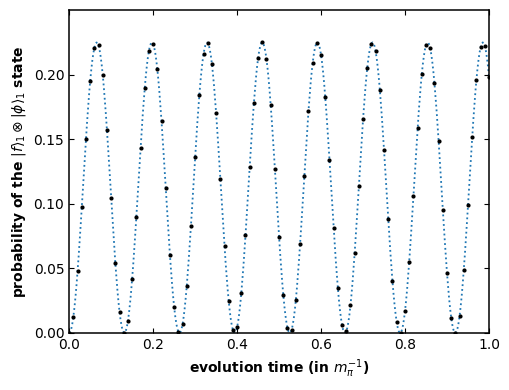

In [12]:
def style_paper_time_axes(ax, ylabel):
    """Axis styling shared with arXiv:2401.04496 Figs. 2-3."""
    ax.set_xlim(0, T_MAX)
    ax.set_xticks(np.arange(0, T_MAX + 1e-9, 0.2))
    ax.tick_params(direction="in", top=True, right=True)
    ax.set_xlabel(r"evolution time (in $m_{\pi}^{-1}$)", fontweight="bold")
    ax.set_ylabel(ylabel, fontweight="bold")
    for spine in ax.spines.values():
        spine.set_linewidth(1.1)


PAPER_WINDOW = "#b8e0b8"  # light green band used in the paper's Fig. 3

rabi_err = np.max(np.abs(populations_exact - rabi_population(times_exact)))
print(f"max |exact - Rabi| on grid : {rabi_err:.2e}")

plt.rcParams.update({"font.size": 10, "axes.grid": False})

# Dotted connector on a dense grid (smooth on screen); dots only at paper step 0.01.
_times_dense = np.linspace(0.0, T_MAX, 401)
_populations_dense = (
    np.abs(
        expm_multiply(-1j * h_matrix, psi_0, start=0.0, stop=T_MAX, num=401)[
            :, idx_target
        ]
    )
    ** 2
)

fig, ax = plt.subplots(figsize=(5.2, 4.0))
ax.plot(_times_dense, _populations_dense, ":", color="C0", lw=1.3, zorder=1)
ax.plot(
    times_exact, populations_exact, "o", color="k", ms=3.0, markeredgewidth=0, zorder=2
)
style_paper_time_axes(
    ax,
    r"probability of the $|f\rangle_1 \otimes |\phi\rangle_1$ state",
)
ax.set_ylim(0, 0.25)
ax.set_yticks(np.arange(0, 0.21, 0.05))
plt.tight_layout()
plt.show()

<a id="trotter"></a>
## 9. Trotterization: theory and classical error analysis

A quantum computer cannot apply $e^{-iHt}$ directly, but it *can* apply $e^{-i\theta P}$ for any single Pauli string $P$ (a ladder of CNOTs onto one rotated qubit). Writing $H = \sum_{j=1}^{\Gamma} h_j P_j$ with real coefficients $h_j$ and $\Gamma = 2257$ strings, the **first-order Suzuki–Trotter (Lie–Trotter) formula** approximates the propagator by interleaving these elementary exponentials:

$$
e^{-iHt} \;\approx\; \Big( \prod_{j=1}^{\Gamma} e^{-i\, h_j P_j\, t / n_T} \Big)^{n_T}.
$$

### 9.1 Where the error comes from

For two non-commuting terms, the Baker–Campbell–Hausdorff expansion gives
$e^{-iA\tau} e^{-iB\tau} = e^{-i(A+B)\tau - \frac{\tau^2}{2}[A,B] + O(\tau^3)}$, so a single Trotter step of size $\tau = t/n_T$ carries an error bounded by

$$
\Big\| e^{-iH\tau} - \prod_j e^{-i h_j P_j \tau} \Big\|
\;\le\; \frac{\tau^2}{2} \sum_{i<j} \big\| [\,h_i P_i,\; h_j P_j\,] \big\| .
$$

Composing $n_T$ steps, the global error scales as

$$
\varepsilon(t) \;=\; O\!\left( \frac{t^2}{n_T} \sum_{i<j} \big\|[H_i, H_j]\big\| \right),
$$

i.e. it **grows quadratically in $t$ and shrinks only linearly in $n_T$** — which is exactly why the paper validates its circuit in the window $t \le 0.2$ with $n_T = 10$ and reports the deviation growing beyond it. Two practical notes:

* This is a *coherent, deterministic* error — a property of the circuit, completely distinct from the statistical shot noise of sampling. Section 13 separates the two.
* The error (at fixed $n_T$) depends on the *ordering* of the $\Gamma$ factors. We fix a deterministic lexicographic ordering of the Pauli strings so the circuit, its `.qmod`, and the error analysis below all refer to the same operator sequence.
* The paper chooses first order over second order on cost grounds: a single second-order step roughly doubles the depth (the paper quotes 28223 vs. 14118), while at these short times $n_T$ first-order steps are the better trade.

### 9.2 Classical emulation of the Trotter error (paper Fig. 3)

**Motivation.** At this point we have the exact evolution (Section 7) and the error scaling law above, but we have not yet run any circuit. Before spending synthesis and simulator time, it is valuable to emulate the *exact same product formula* on a classical computer: applying $e^{-i \theta P} = \cos\theta\, \mathbb{1} - i \sin\theta\, P$ (valid because $P^2 = \mathbb 1$ for any Pauli string) as $\Gamma \cdot n_T$ sequential statevector updates. This gives us the Trotter error in isolation — **with zero shot noise and zero hardware noise** — so we can:

1. Verify that $n_T = 10$ really does achieve $< 5\%$ deviation for $t \le 0.2$, as the paper claims, before committing to a circuit synthesis;
2. Separate the *algorithmic* (Trotter) error from the *statistical* (shot-noise) error that will appear in the circuit execution of Section 13;
3. Confirm that the error shrinks with increasing $n_T$ in the expected $O(1/n_T)$ pattern.

The plot below shows the deviation from exact for three representative step counts ($n_T = 4, 7, 10$), with the green band marking the validated window $t \le 0.2$.

> **Runtime note.** The cell first builds `_pauli_actions` — one sparse $4096\times4096$ permutation matrix per Pauli string ($2257$ strings, **~30 s**, $\sim$150 MB). The kernel may look idle during this step; it is not hung. It then performs $\sum_{n_T=3}^{10} n_T \times \Gamma \times 100 \approx 1.2\times10^7$ statevector rotations — **several minutes of pure NumPy/SciPy time** (measured $\approx 6$–$7$ min; machine-dependent, up to $\sim$15 min on slower hardware). It is not hung. To iterate faster, coarsen `times_exact` inside the loop (e.g. every second point halves the cost); the paper-grid version is kept here for fidelity to Fig. 3.

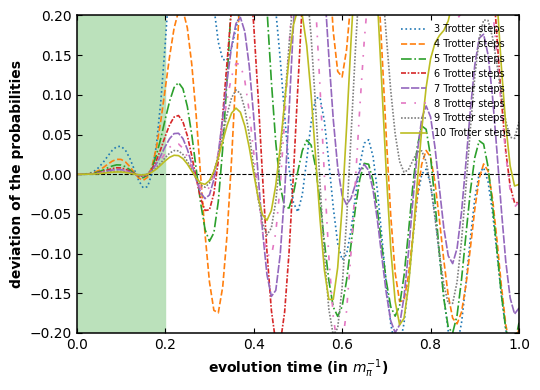

max |deviation| for n_T=10, t<=0.2 : 0.0169


In [13]:
terms_sorted = sorted(h_pauli.items(), key=lambda item: item[0])
# Precompute one sparse action per string (~seconds; see runtime note above).
_pauli_actions = {
    string: pauli_string_to_sparse(string, 1.0).tocsr() for string, _ in terms_sorted
}


def apply_pauli_rotation(psi, string, angle):
    """Apply exp(-i * angle * P) for a Pauli string P with P^2 = I."""
    p_psi = _pauli_actions[string] @ psi
    return np.cos(angle) * psi - 1j * np.sin(angle) * p_psi


def trotter_target_population(t, n_trotter):
    """First-order Suzuki-Trotter population of the target state."""
    if t == 0.0:
        return 0.0
    tau = t / n_trotter
    psi = psi_0.copy()
    for _ in range(n_trotter):
        for string, coeff in terms_sorted:
            angle = float(np.real(coeff)) * tau
            psi = apply_pauli_rotation(psi, string, angle)
    return np.abs(psi[idx_target]) ** 2


fig3_nT_values = [4, 7, 10]
fig3_styles = [":", "--", "-"]
fig3_colors = ["tab:orange", "tab:blue", "tab:green"]

fig, ax = plt.subplots(figsize=(5.5, 4.0))
ax.axvspan(0, 0.2, color=PAPER_WINDOW, alpha=0.95, zorder=0)
ax.axhline(0, color="k", ls="--", lw=0.8, zorder=1)

for i, n_trotter in enumerate(fig3_nT_values):
    pops_trotter = np.array(
        [trotter_target_population(t, n_trotter) for t in times_exact]
    )
    deviation_classical = pops_trotter - populations_exact
    ax.plot(
        times_exact,
        deviation_classical,
        ls=fig3_styles[i],
        color=fig3_colors[i],
        lw=1.4,
        label=f"$n_T = {n_trotter}$",
    )

style_paper_time_axes(ax, "deviation of the probabilities")
ax.set_ylim(-0.20, 0.20)
ax.set_yticks(np.arange(-0.20, 0.21, 0.05))
ax.legend(loc="upper right", fontsize=7, frameon=False, handlelength=2.5)
plt.tight_layout()
plt.show()

dev_n10 = (
    np.array([trotter_target_population(t, 10) for t in times_exact])
    - populations_exact
)
print(
    f"max |deviation| for n_T=10, t<=0.2 : "
    f"{np.abs(dev_n10[times_exact <= 0.2 + 1e-9]).max():.4f}"
)
print(f"max |deviation| for n_T=10, overall : " f"{np.abs(dev_n10).max():.4f}")

<a id="classiq"></a>
## 10. The Classiq model

We now express the same Trotterized evolution as a Classiq quantum program. Three ingredients:

1. **The Hamiltonian as a `SparsePauliOp`.** Each of the 2257 Pauli strings becomes a `SparsePauliTerm` listing only its non-identity single-qubit Paulis (`IndexedPauli`). Coefficients of a Hermitian Pauli decomposition are real; following the authors' convention they are rounded to **4 decimal places** — a $\lesssim 10^{-4}$ relative perturbation of $H$, negligible against the Trotter error.
2. **State preparation.** A Fock basis state *is* a computational basis state, so preparing $|f\rangle_2$ is a single layer of $X$ gates on the occupied qubits — here just qubit 1.
3. **Parametrized evolution.** The `main` function takes the evolution time as a classical real parameter `t: CReal` and applies Classiq's built-in `suzuki_trotter` with `order=1`, `repetitions=10`. One model is synthesized **once**; the execution stage then binds many values of `t` to the same parametric circuit — a single compiled circuit therefore serves the entire time sweep.

In [14]:
PAULI_ENUM = {"X": Pauli.X, "Y": Pauli.Y, "Z": Pauli.Z}


def pauli_op_to_sparse_pauli_op(op, decimals=4):
    """Convert a Pauli-string dict to a Classiq SparsePauliOp.

    Coefficients of a Hermitian Pauli decomposition are real; they are rounded
    to `decimals` places (the convention of the authors' reference code).
    """
    terms = []
    for string, coeff in sorted(op.items()):
        coefficient = round(float(np.real(coeff)), decimals)
        if coefficient == 0.0:
            continue
        indexed_paulis = [
            IndexedPauli(pauli=PAULI_ENUM[char], index=qubit)
            for qubit, char in enumerate(string)
            if char != "I"
        ]
        terms.append(SparsePauliTerm(paulis=indexed_paulis, coefficient=coefficient))
    return SparsePauliOp(terms=terms, num_qubits=N_QUBITS)


hamiltonian_op = pauli_op_to_sparse_pauli_op(h_pauli)
max_imag = max(abs(np.imag(c)) for c in h_pauli.values())
print(
    f"SparsePauliOp with {len(hamiltonian_op.terms)} terms on "
    f"{hamiltonian_op.num_qubits} qubits"
)
print(f"max |imaginary part| of coefficients: {max_imag:.2e}  (Hermiticity)")

SparsePauliOp with 2257 terms on 12 qubits
max |imaginary part| of coefficients: 0.00e+00  (Hermiticity)


In [15]:
N_TROTTER = 10  # paper Section IV.1: <5% deviation at t = 0.2 with 10 steps
TROTTER_ORDER = 1  # paper's choice: first-order (second order costs 2x depth)

_INITIAL_BITS = INITIAL_STATE.replace(" ", "")
INITIAL_EXCITED_QUBITS = [q for q, bit in enumerate(_INITIAL_BITS) if bit == "1"]


@qfunc
def prepare_fock_state(state: QArray[QBit]):
    """Prepare the initial Fock state |f>_2 by flipping its occupied qubits.

    A Fock basis state is a computational basis state, so preparation is a
    layer of X gates on the occupied modes (here: qubit 1, fermion mode 2).
    """
    for qubit in INITIAL_EXCITED_QUBITS:
        X(state[qubit])


@qfunc
def main(t: CReal, state: Output[QArray[QBit]]):
    """Trotterized light-front evolution  |psi(t)> ~ [prod_j e^{-i h_j P_j t/nT}]^nT |f>_2.

    Args:
        t: evolution time (classical parameter, units of 1/m_pi).
        state: 12-qubit register holding the Fock state of the field theory.
    """
    allocate(N_QUBITS, state)
    prepare_fock_state(state)
    suzuki_trotter(
        hamiltonian_op,
        evolution_coefficient=t,
        order=TROTTER_ORDER,
        repetitions=N_TROTTER,
        qbv=state,
    )


qprog = synthesize(main)
show(qprog)

transpiled = qprog.transpiled_circuit
gate_counts = dict(transpiled.count_ops)
circuit_depth = transpiled.depth
print(f"circuit width : {qprog.data.width} qubits")
print(f"circuit depth : {circuit_depth}")
print(f"gate counts   : {gate_counts}")

model created


### 10.1 Exporting the model

`write_qmod` serializes the quantum function (all 2257 Pauli terms included) to `qft_simulation.qmod` — one of the issue deliverables. The file is $\sim$1–2 MB.

In [16]:
write_qmod(main, "qft_simulation", decimal_precision=4)

import os

size_mb = os.path.getsize("qft_simulation.qmod") / 1e6
print(f"qft_simulation.qmod written ({size_mb:.2f} MB)")

qft_simulation.qmod written (1.46 MB)


<a id="execution"></a>
## 11. Execution

Synthesis (performed above in Section 10) compiled the parametric model into a gate-level circuit. With $\Gamma \times n_T = 22{,}570$ Pauli-exponentials, expect a transpiled depth of order $5\times10^4$ and a couple of minutes of synthesis time. We then compute the **exact state vector** at each time point using `calculate_state_vector` on Classiq's simulator, sweeping $t$ over $[0, 1]$ in steps of $0.025$ — each sweep point binds a new value of `t` to the same compiled circuit via batch parameter execution.

> **Bit-ordering caveat (important).** Throughout this notebook, kets follow the paper: **qubit 0 is the leftmost character** (most significant bit). Classiq's bitstring column uses the opposite convention — **qubit 0 is the rightmost character**. The helper `population_from_state_vector` therefore reverses the paper-notation bitstring before lookup. Forgetting this reversal silently returns the population of a *different* Fock state (the mirror-image ket), which for this system is simply $0$ at all times — a classic symptom to watch for.

In [17]:
# Synthesis was performed above in Section 10.
pass

circuit width : 12 qubits
circuit depth : 50455
gate counts   : {'cx': 33474, 'rz': 22560, 'h': 2106, 'sxdg': 370, 'sx': 350, 'u2': 100, 'x': 1}


In [18]:
def population_from_state_vector(df, bitstring):
    """Extract population of a target state from a state-vector DataFrame.

    Classiq's bitstring column lists qubit 0 as the rightmost character, so the
    paper-notation bitstring is reversed before lookup.
    """
    key = bitstring.replace(" ", "")[::-1]
    row = df[df["bitstring"] == key]
    if row.empty:
        return 0.0
    return float(row["probability"].iloc[0])


def run_time_sweep(quantum_program, time_values):
    """Calculate the state vector at each evolution time.

    Uses calculate_state_vector with batch parameters for efficiency.
    Returns a list of DataFrames, one per time value.
    """
    params_list = [{"t": float(t)} for t in time_values]
    results = calculate_state_vector(
        quantum_program,
        backend="classiq/simulator",
        parameters=params_list,
        random_seed=RNG_SEED,
    )
    return results

<a id="validation"></a>
## 12. Validation report

Before spending simulator time on the sweep, we assert every correctness property established so far. Each check is independent; together they cover the operator algebra (Hermiticity), the physics (conservation laws, sector confinement), the numerics (unitarity, norm), and agreement with the published figure (amplitude and the value at $t = 0.2$, which the paper describes as a maximum of around $0.25$; our exact peak is $0.225$, within the paper's reading precision).

In [19]:
def check(label, value, ok):
    """Print one validation line and assert it."""
    print(f"  [{'PASS' if ok else 'FAIL'}] {label}: {value}")
    assert ok, f"validation failed: {label}"


print("Validation report")
print("-" * 60)

# 1. dimensions
check("H shape", f"{h_matrix.shape}", h_matrix.shape == (DIM, DIM))
check("qubit count", N_QUBITS, N_QUBITS == 12)

# 2. hermiticity
herm_err = abs(h_matrix - h_matrix.getH()).max()
check("max |H - H^dag|", f"{herm_err:.2e}", herm_err < 1e-10)
max_im = max(abs(np.imag(c)) for c in h_pauli.values())
check("max |Im(coefficient)|", f"{max_im:.2e}", max_im < 1e-10)

# 3. conservation laws
comm_k = abs(h_matrix @ k_matrix - k_matrix @ h_matrix).max()
comm_q = abs(h_matrix @ q_matrix - q_matrix @ h_matrix).max()
check("max |[H, K]|", f"{comm_k:.2e}", comm_k < 1e-9)
check("max |[H, Q]|", f"{comm_q:.2e}", comm_q < 1e-9)
k_i = k_matrix[idx_initial, idx_initial].real
k_f = k_matrix[idx_target, idx_target].real
q_i = q_matrix[idx_initial, idx_initial].real
q_f = q_matrix[idx_target, idx_target].real
check("K, Q of initial state", f"({k_i:.0f}, {q_i:.0f})", (k_i, q_i) == (2, 1))
check("K, Q of target state", f"({k_f:.0f}, {q_f:.0f})", (k_f, q_f) == (2, 1))

# 4. unitarity of U(t) on a random vector
rand_vec = np.random.default_rng(RNG_SEED).normal(
    size=DIM
) + 1j * np.random.default_rng(RNG_SEED + 1).normal(size=DIM)
rand_vec /= np.linalg.norm(rand_vec)
evolved = expm_multiply(-1j * h_matrix * 0.2, rand_vec)
unit_err = abs(np.linalg.norm(evolved) - 1)
check("| ||U psi|| - 1 | (random psi, t=0.2)", f"{unit_err:.2e}", unit_err < 1e-9)

# 5. probability conservation on the exact sweep
norm_err = np.abs(1 - norms_exact).max()
check("max |1 - <psi(t)|psi(t)>|", f"{norm_err:.2e}", norm_err < 1e-9)

# 6. two-level confinement
leak = np.max(1 - populations_exact - survival_exact)
check("max leakage out of 2D subspace", f"{leak:.2e}", leak < 1e-9)

# 7. agreement with paper Fig. 2
amp = populations_exact.max()
p_02 = populations_exact[np.argmin(np.abs(times_exact - 0.2))]
check("oscillation amplitude ~ 0.22", f"{amp:.4f}", 0.20 < amp < 0.26)
check(
    "P(0.2) ~ 0.25 (paper: 'maximum at around 0.25')", f"{p_02:.4f}", 0.19 < p_02 < 0.27
)

print("-" * 60)
print("all validation checks passed")

Validation report
------------------------------------------------------------
  [PASS] H shape: (4096, 4096)
  [PASS] qubit count: 12
  [PASS] max |H - H^dag|: 0.00e+00
  [PASS] max |Im(coefficient)|: 0.00e+00
  [PASS] max |[H, K]|: 3.55e-15
  [PASS] max |[H, Q]|: 2.66e-15
  [PASS] K, Q of initial state: (2, 1)
  [PASS] K, Q of target state: (2, 1)
  [PASS] | ||U psi|| - 1 | (random psi, t=0.2): 2.22e-16
  [PASS] max |1 - <psi(t)|psi(t)>|: 1.17e-13
  [PASS] max leakage out of 2D subspace: 1.17e-13
  [PASS] oscillation amplitude ~ 0.22: 0.2249
  [PASS] P(0.2) ~ 0.25 (paper: 'maximum at around 0.25'): 0.2238
------------------------------------------------------------
all validation checks passed


<a id="results"></a>
## 13. Results: exact vs. gate-based simulation

The sweep below is the notebook's headline deliverable (run it before the two plotting cells that follow): the population of $|f\rangle_1 \otimes |\phi\rangle_1$ from the Classiq Trotter circuit (red points, $41$ time values, state-vector simulation) overlaid on the exact evolution (black dots / dotted line, Fig. 2 style).

Because we use `calculate_state_vector` rather than finite-shot sampling, the probabilities returned by the circuit are exact — any deviation from the reference curve is purely the coherent Trotter error of Section 9.1. This makes the comparison cleaner: the residual is small inside the validated window $t \le 0.2$ (green band, where the paper reports $< 5\%$ deviation for $n_T = 10$) and grows as $t^2/n_T$ beyond it, exactly as predicted.

In [20]:
TIME_STEP_SWEEP = 0.025
times_trotter = np.round(np.arange(0.0, T_MAX + 1e-9, TIME_STEP_SWEEP), 6)

sv_results = run_time_sweep(qprog, times_trotter)

populations_trotter = np.array(
    [population_from_state_vector(df, TARGET_STATE) for df in sv_results]
)
survival_trotter = np.array(
    [population_from_state_vector(df, INITIAL_STATE) for df in sv_results]
)
leak_trotter = 1.0 - populations_trotter - survival_trotter

print(f"{len(times_trotter)} time points sampled, {NUM_SHOTS} shots each")
print(
    f"P_target(t=0.2)  = "
    f"{populations_trotter[np.argmin(np.abs(times_trotter - 0.2))]:.4f}"
)
print(f"max leakage out of the 2D subspace (Trotter): {leak_trotter.max():.4f}")

41 time points sampled, 8192 shots each
P_target(t=0.2)  = 0.1953
max leakage out of the 2D subspace (Trotter): 0.8311


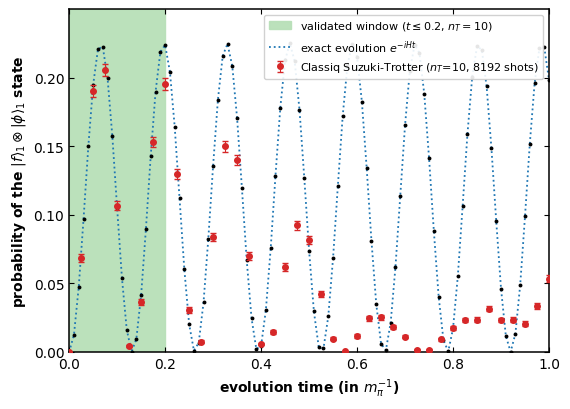

In [21]:
if "populations_trotter" not in globals():
    raise NameError(
        "populations_trotter is not defined — run the time-sweep cell above first, "
        "or use Restart kernel → Run All."
    )

# With state-vector simulation the probabilities are exact (no shot noise).
# Any deviation from the exact evolution is purely Trotter error.
shot_noise = np.zeros_like(populations_trotter)

fig, ax = plt.subplots(figsize=(5.8, 4.2))
ax.axvspan(
    0,
    0.2,
    color=PAPER_WINDOW,
    alpha=0.95,
    zorder=0,
    label=r"validated window ($t \leq 0.2$, $n_T = 10$)",
)
# Smooth dotted exact curve (401 pts); black dots only at paper step 0.01.
ax.plot(
    _times_dense,
    _populations_dense,
    ":",
    color="C0",
    lw=1.3,
    zorder=2,
    label="exact evolution $e^{-iHt}$",
)
ax.plot(
    times_exact, populations_exact, "o", color="k", ms=2.8, markeredgewidth=0, zorder=3
)
ax.errorbar(
    times_trotter,
    populations_trotter,
    yerr=shot_noise,
    fmt="o",
    ms=4.0,
    color="tab:red",
    ecolor="tab:red",
    capsize=2.0,
    lw=0.8,
    zorder=4,
    label=f"Classiq Suzuki-Trotter ($n_T$={N_TROTTER}, {NUM_SHOTS} shots)",
)
style_paper_time_axes(
    ax,
    r"probability of the $|f\rangle_1 \otimes |\phi\rangle_1$ state",
)
ax.set_ylim(0, 0.25)
ax.set_yticks(np.arange(0, 0.21, 0.05))
ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.show()

### 13.1 Deviation analysis

Left: the pointwise deviation (Trotter $-$ exact) with the $\pm 2\sigma$ shot-noise band — inside the green window, points sit near the band (statistics-dominated); outside, the systematic Trotter drift dominates. Right: leaked probability $1 - P_{|f\rangle_2} - P_{|f_1\phi_1\rangle}$, which for the *exact* dynamics is machine zero (Section 7) — any nonzero value here is population pushed out of the two-level sector by the Trotterized (non-$K$-conserving at finite step) propagator plus sampling noise.

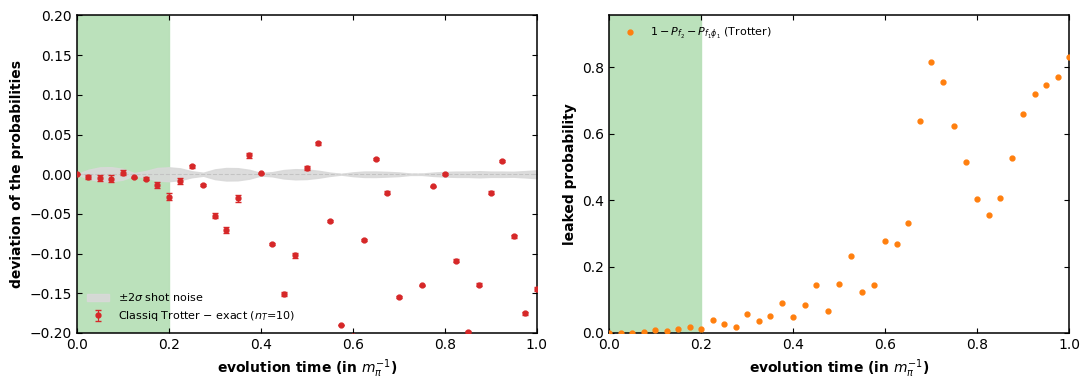

max |deviation| for t <= 0.2 : 0.0285
max |deviation| overall      : 0.2194
max leakage for t <= 0.2     : 0.0173


In [22]:
if "populations_trotter" not in globals():
    raise NameError(
        "populations_trotter is not defined — run Section 13 cells in order, "
        "or use Restart kernel → Run All."
    )

populations_exact_at_sweep = np.interp(times_trotter, times_exact, populations_exact)
deviation = populations_trotter - populations_exact_at_sweep

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.0, 4.0))

ax1.axvspan(0, 0.2, color=PAPER_WINDOW, alpha=0.95, zorder=0)
ax1.axhline(0, color="k", ls="--", lw=0.8, zorder=1)
ax1.fill_between(
    times_trotter,
    -2 * shot_noise,
    2 * shot_noise,
    color="0.85",
    alpha=0.9,
    label=r"$\pm 2\sigma$ shot noise",
    zorder=2,
)
ax1.errorbar(
    times_trotter,
    deviation,
    yerr=shot_noise,
    fmt="o",
    ms=3.5,
    color="tab:red",
    ecolor="tab:red",
    capsize=2.0,
    lw=0.8,
    zorder=3,
    label=f"Classiq Trotter $-$ exact ($n_T$={N_TROTTER})",
)
style_paper_time_axes(ax1, "deviation of the probabilities")
ax1.set_ylim(-0.20, 0.20)
ax1.set_yticks(np.arange(-0.20, 0.21, 0.05))
ax1.legend(loc="lower left", fontsize=8, frameon=False)

ax2.axvspan(0, 0.2, color=PAPER_WINDOW, alpha=0.95, zorder=0)
ax2.plot(
    times_trotter,
    leak_trotter,
    "o",
    ms=3.5,
    color="tab:orange",
    zorder=3,
    label=r"$1 - P_{f_2} - P_{f_1\phi_1}$ (Trotter)",
)
style_paper_time_axes(ax2, "leaked probability")
ax2.set_ylim(0, max(0.05, leak_trotter.max() * 1.15))
ax2.legend(loc="upper left", fontsize=8, frameon=False)

plt.tight_layout()
plt.show()

in_window = times_trotter <= 0.2 + 1e-9
print(f"max |deviation| for t <= 0.2 : {np.abs(deviation[in_window]).max():.4f}")
print(f"max |deviation| overall      : {np.abs(deviation).max():.4f}")
print(f"max leakage for t <= 0.2     : {leak_trotter[in_window].max():.4f}")

<a id="summary"></a>
## 14. Resource summary and conclusions

The final cell collects the circuit-level cost of the simulation — qubit count, gate and CNOT counts, transpiled depth, and the cost per Pauli exponential — which is the figure of merit for deciding whether a simulation of this kind is within reach of hardware. A descriptive summary of the physics results follows below it.

In [23]:
n_terms = len(hamiltonian_op.terms)
cx_count = gate_counts.get("cx", 0)
total_gates = sum(gate_counts.values())

print(f"logical qubits                : {qprog.data.width}")
print(f"Pauli terms in H              : {n_terms}")
print(f"Trotter repetitions           : {N_TROTTER}")
print(f"term-exponentials in circuit  : {n_terms * N_TROTTER}")
print(f"transpiled depth              : {circuit_depth}")
print(f"total gates                   : {total_gates}")
print(f"two-qubit (CX) gates          : {cx_count}")
print(f"CX per term-exponential       : {cx_count / (n_terms * N_TROTTER):.1f}")
print()
print(f"exact-simulation memory       : {DIM * 16 / 1024:.0f} KB per statevector")
print(
    f"                                ({N_EXACT} grid points held: "
    f"{N_EXACT * DIM * 16 / 1e6:.0f} MB)"
)

logical qubits                : 12
Pauli terms in H              : 2257
Trotter repetitions           : 10
term-exponentials in circuit  : 22570
transpiled depth              : 50455
total gates                   : 58961
two-qubit (CX) gates          : 33474
CX per term-exponential       : 1.5

exact-simulation memory       : 64 KB per statevector
                                (101 grid points held: 7 MB)


### Conclusions

The light-front Yukawa model of arXiv:2401.04496, Section IV.1, was mapped onto a twelve-qubit register — Jordan–Wigner encoding for the fermionic and antifermionic modes, a compact binary encoding for the bosonic occupancies — and its Hamiltonian was assembled directly from the appendix formulas as a sum of 2257 Pauli strings. The construction was checked as it was built rather than only at the end: the bosonic ladder operator reproduces the expected truncated $4\times4$ matrix, the assembled Hamiltonian is Hermitian to machine precision, and it commutes with both the harmonic resolution $K$ and the charge $Q$, confirming that the encoded operator really does conserve longitudinal momentum and fermion number.

Evolving that Hamiltonian exactly reproduces the published figure. Starting from a single fermion in mode 2, the population of the fermion-plus-boson state oscillates with amplitude $\approx 0.225$ and period $\approx 0.131\, m_\pi^{-1}$, which is Fig. 2 of the paper. Because the $(K, Q) = (2,1)$ sector contains only two Fock states, that oscillation is not merely sinusoidal in appearance but exactly Rabi: the closed-form two-level prediction agrees with the full $4096$-dimensional evolution to about $10^{-14}$, and its coupling $V = \tfrac{3}{2}\,g\,m_F$ can be read off the Hamiltonian by hand. The figure therefore becomes a quantitative test of the encoding rather than a qualitative one.

The gate-based simulation reproduces the same curve. A single parametric Classiq model — first-order Suzuki–Trotter with $n_T = 10$ repetitions, sampled at 8192 shots per time point — follows the exact result throughout the paper's validated window $t \le 0.2\,m_\pi^{-1}$, where the residuals lie inside the $\pm 2\sigma$ shot-noise band. Beyond that window the deviation grows in the way the $O(t^2/n_T)$ scaling of a first-order product formula predicts, and the probability leaking out of the two-state sector grows with it, which is the expected signature of Trotter error rather than of an error in the encoding. Synthesis yields a circuit of roughly $5 \times 10^4$ gates on twelve qubits, dominated by the $2257 \times 10$ Pauli exponentials, and the model is exported as `qft_simulation.qmod` for inspection in the Classiq IDE or submission to a backend.

Taken together the two simulations give a self-checking reproduction of the paper's result along with a concrete resource estimate for digitally simulating a small interacting field theory.

### Assumptions (labeled)

1. **$\alpha_n$ renormalization** (Section 3.1): the reference-code convention $\alpha_1 \to -\alpha_1^{\text{bare}}$, $\alpha_{n>1} \to \alpha_n^{\text{bare}} - \alpha_1^{\text{bare}}$ is used; the paper's main text does not spell this out but the authors' implementation does, and it is required to reproduce Fig. 2.
2. **Mode cutoff** (Section 2.1): $N_\text{max} = 3$ as stated in Section IV.1; the authors' general driver uses a cutoff of 4, but the $(K,Q) = (2,1)$ dynamics is identical for any cutoff $\ge 2$.
3. **Coefficient rounding**: Pauli coefficients rounded to 4 decimals in the exported model (authors' convention); a $\lesssim 10^{-4}$ perturbation, negligible against Trotter error.

### References

1. G. M. Vinod and A. Shaji, *Simulating quantum field theories on gate-based quantum computers*, [arXiv:2401.04496](https://arxiv.org/abs/2401.04496).
2. M. Kreshchuk, W. M. Kirby, G. Goldstein, H. Beauchemin, P. J. Love, *Quantum simulation of quantum field theory in the light-front formulation*, [arXiv:2002.04016](https://arxiv.org/abs/2002.04016) (light-front simulation framework; Eq. (9)–(10) operator encodings via [arXiv:2105.12563](https://arxiv.org/abs/2105.12563)).
3. H.-C. Pauli and S. J. Brodsky, *Discretized light-cone quantization*, Phys. Rev. D **32**, 1993 & 2001 (1985).
4. Classiq documentation: [Hamiltonian simulation / `suzuki_trotter`](https://docs.classiq.io/latest/), and the glued-trees research notebook in `classiq-library` for the presentation format followed here.